In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import json

In [2]:
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

X_train = pd.read_csv(f'{path}X_train_80.csv')
y_train = pd.read_csv(f'{path}y_train_80.csv').squeeze()

----------------------------------------
Running Recursive Feature Elimination (RFE)...
----------------------------------------
Top 10 Features Selected:


,Feature,Selected,Rank
0,Age,True,1
17,Fasting Blood Sugar,True,1
16,Triglyceride Level,True,1
14,Sleep Hours,True,1
18,CRP Level,True,1
8,BMI,True,1
19,Homocysteine Level,True,1
4,Exercise Habits,True,1
3,Cholesterol Level,True,1
2,Blood Pressure,True,1


/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_2383/3662430896.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Rank', y='Feature', palette='viridis')


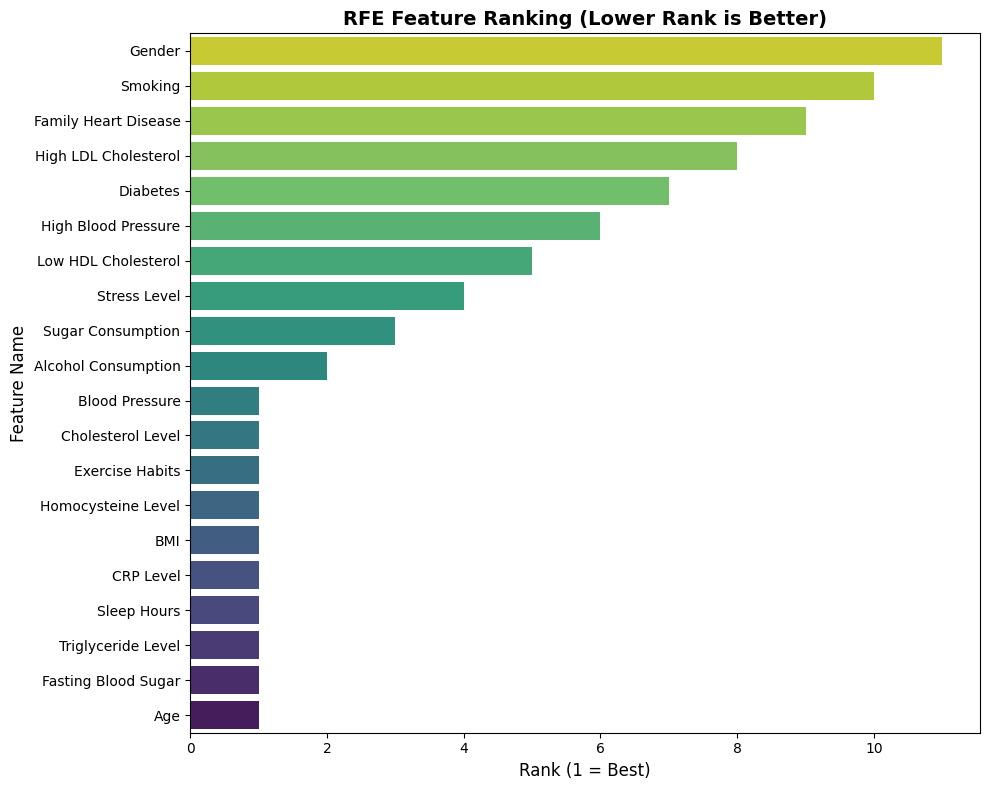

In [3]:
# ==========================================
# 🔍 RFE: คัดเลือกตัวแปร (Feature Selection)
# ==========================================
print("-" * 40)
print('Running Recursive Feature Elimination (RFE)...')
print("-" * 40)

# 1. ตั้งกรรมการตัดสิน (Estimator)
# ใช้ Random Forest เพราะเก่งเรื่องหาความสัมพันธ์ซับซ้อน
estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. กำหนดจำนวนผู้ชนะ
# n_features_to_select=10 คือเราอยากได้ Top 10 ตัว (ปรับเลขนี้ได้ตามใจชอบ)
# step=1 คือคัดออกทีละ 1 ตัว
selector = RFE(estimator, n_features_to_select=10, step=1)

# 3. เริ่มการแข่งขัน (Fit กับข้อมูล Train)
# .values.ravel() ใช้เพื่อแปลง y_train ให้เป็น array 1 มิติ (กัน Error)
selector = selector.fit(X_train, y_train.values.ravel())

# 4. สรุปผลคะแนน
rfe_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': selector.support_,  # True=ถูกเลือก, False=ตกรอบ
    'Rank': selector.ranking_       # 1=ชนะเลิศ (Top 10), เลขเยอะ=ตกรอบแรกๆ
})

# เรียงลำดับตาม Rank (น้อยไปมาก)
rfe_results = rfe_results.sort_values(by='Rank')

print("Top 10 Features Selected:")
display(rfe_results.head(10))

# ==========================================
# 📊 กราฟแสดงความสำคัญ (Top 20 Features)
# ==========================================
# เอาเฉพาะ Top 20 มาพลอตดู
top_features = rfe_results.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x='Rank', y='Feature', palette='viridis')
plt.title('RFE Feature Ranking (Lower Rank is Better)', fontsize=14, fontweight='bold')
plt.xlabel('Rank (1 = Best)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.gca().invert_yaxis() # ให้ Rank 1 อยู่บนสุด
plt.tight_layout()
plt.show()

In [4]:
import joblib
import os

# 1. ดึงชื่อเฉพาะตัวที่ได้ Rank == 1 (The Winner)
# จากกราฟ ตัวเองจะเห็นว่ามี 10 ตัวเป๊ะเลย
selected_features = rfe_results[rfe_results['Rank'] == 1]['Feature'].tolist()

print(f"✅ Features ที่ผ่านเข้ารอบ ({len(selected_features)} ตัว):")
print(selected_features)

# 2. สร้างโฟลเดอร์ models (ถ้ายังไม่มี) และบันทึก
os.makedirs('models', exist_ok=True)
joblib.dump(selected_features, 'models/rfe_best_features.pkl')

print("\n✓ บันทึกรายชื่อ 'models/rfe_best_features.pkl' เรียบร้อย!")
print(">> ตอนนี้ปิดไฟล์นี้ แล้วไปเปิดไฟล์ใหม่สำหรับเทรนโมเดลได้เลยค่ะ! 🎉")

✅ Features ที่ผ่านเข้ารอบ (10 ตัว):
['Age', 'Fasting Blood Sugar', 'Triglyceride Level', 'Sleep Hours', 'CRP Level', 'BMI', 'Homocysteine Level', 'Exercise Habits', 'Cholesterol Level', 'Blood Pressure']

✓ บันทึกรายชื่อ 'models/rfe_best_features.pkl' เรียบร้อย!
>> ตอนนี้ปิดไฟล์นี้ แล้วไปเปิดไฟล์ใหม่สำหรับเทรนโมเดลได้เลยค่ะ! 🎉
